# End-to-End Sales Forecasting & Demand Intelligence System

**Author:** Gnana Prashanth Reddy — Week 3 & 4
**Dataset:** Superstore Sales (train.csv) + Video Game Sales (vgsales.csv, supplementary)

This notebook works through 8 tasks:
1. Data loading, merging & exploration
2. Time series decomposition & stationarity testing
3. Forecasting with 3 different models (SARIMA, Prophet, XGBoost)
4. Category/region-level forecasting
5. Anomaly detection (Isolation Forest + Z-Score)
6. Product demand segmentation (K-Means clustering)
7. Streamlit dashboard (built as a separate `app.py` file, see submission folder)
8. Executive business report (separate `summary.docx`, see submission folder)


## Task 1 — Data Loading, Merging & Deep Exploration

We start by loading the Superstore sales data, fixing data types, and engineering time-based
features (year, month, week, quarter, season) that later tasks will need.


In [6]:
# Basic imports we'll need throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')  # statsmodels/prophet print a lot of harmless warnings

# Load the raw CSV
df = pd.read_csv("train.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
# Check data quality: missing values, duplicate rows, and column data types
print("Missing values per column:\n", df.isnull().sum())
print("\nNumber of exact duplicate rows:", df.duplicated().sum())
print("\nColumn data types:\n", df.dtypes)

# Note: Postal Code has a few missing values, but we don't use that column for forecasting,
# so we leave it as-is rather than dropping rows.

Missing values per column:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Number of exact duplicate rows: 0

Column data types:
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [8]:
# The date columns are currently plain text (strings), e.g. "08/11/2017".
# We convert them into real datetime objects so pandas can do date math (subtracting dates,
# grouping by month, etc). The format is day/month/year based on the raw file.
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%d/%m/%Y')

print("Date range covered:", df['Order Date'].min(), "to", df['Order Date'].max())

Date range covered: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [9]:
# Feature engineering: pull useful time-based features out of the Order Date.
# These will be used later both for exploration and as model inputs.
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week']  = df['Order Date'].dt.isocalendar().week   # ISO week number (1-52)
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df['Order Quarter'] = df['Order Date'].dt.quarter

# A simple function that maps a calendar month to a season.
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Order Month'].apply(get_season)

# How many days between when the order was placed and when it shipped?
df['Shipping Delay (days)'] = (df['Ship Date'] - df['Order Date']).dt.days

df[['Order Date','Order Year','Order Month','Order Week','Season','Shipping Delay (days)']].head()

,Order Date,Order Year,Order Month,Order Week,Season,Shipping Delay (days)
0,2017-11-08,2017,11,45,Fall,3
1,2017-11-08,2017,11,45,Fall,3
2,2017-06-12,2017,6,24,Summer,4
3,2016-10-11,2016,10,41,Fall,7
4,2016-10-11,2016,10,41,Fall,7


In [10]:
# Aggregate the raw (one-row-per-item) data into weekly and monthly TOTAL sales.
# We need both granularities: monthly for the forecasting models (Tasks 3-4),
# weekly for anomaly detection (Task 5), which needs more data points to be meaningful.
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()  # 'MS' = Month Start
weekly_sales  = df.set_index('Order Date').resample('W')['Sales'].sum()   # 'W' = Week (Sun-ending)

print("Number of months in dataset:", len(monthly_sales))
print("Number of weeks in dataset:", len(weekly_sales))
monthly_sales.head()

Number of months in dataset: 48
Number of weeks in dataset: 209


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

### Answering the required exploration questions

In [11]:
# Q1: Which product category generates the highest total revenue?
revenue_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Total revenue by category:\n", revenue_by_category)
print(f"\n>>> Answer: '{revenue_by_category.index[0]}' generates the most revenue "
      f"(${revenue_by_category.iloc[0]:,.0f}).")

Total revenue by category:
 Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

>>> Answer: 'Technology' generates the most revenue ($827,456).


In [12]:
# Q2: Which region has the most consistent sales growth over the 4 years?
# We pivot so rows = region, columns = year, and look for the region whose sales
# increase EVERY single year (rather than one that just has the highest total).
yearly_by_region = df.groupby(['Region','Order Year'])['Sales'].sum().unstack()
print(yearly_by_region)

# A region is "consistently growing" if each year's total is bigger than the previous year's.
for region in yearly_by_region.index:
    values = yearly_by_region.loc[region].values
    is_always_increasing = all(values[i] < values[i+1] for i in range(len(values)-1))
    print(f"{region}: increases every year = {is_always_increasing}")

Order Year         2015         2016         2017         2018
Region                                                        
Central     102920.5206  102425.1724  145673.8800  141627.3402
East        127652.8190  153225.1830  178511.5380  210129.1860
South       103374.9055   70076.0825   93535.9035  122164.5675
West        145907.9630  133709.5675  182471.2285  248130.9255
Central: increases every year = False
East: increases every year = True
South: increases every year = False
West: increases every year = False


**Answer:** The **East** region increases every single year (2015 → 2016 → 2017 → 2018),
making it the most *consistently* growing region. West has a higher total by 2018, but it dipped
in 2016, so its growth is less consistent.

In [13]:
# Q3: What is the average shipping delay, and does it vary by region?
print("Overall average shipping delay:", round(df['Shipping Delay (days)'].mean(), 2), "days")
print("\nAverage shipping delay by region:\n", df.groupby('Region')['Shipping Delay (days)'].mean().round(2))
# Answer: delay is ~4 days everywhere, and barely varies by region (differences are a few hours, not days) 
# So shipping speed looks like a company-wide policy rather than a regional issue.

Overall average shipping delay: 3.96 days

Average shipping delay by region:
 Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: Shipping Delay (days), dtype: float64


In [14]:
# Q4: Are there months that consistently spike across all years (seasonality)?
monthly_totals_by_month = df.groupby('Order Month')['Sales'].sum().sort_values(ascending=False)
print("Total sales by calendar month (summed across all 4 years):\n", monthly_totals_by_month)
# Answer: November, September, and December stand out clearly - this lines up with
# back-to-school (Sept) and holiday/year-end (Nov-Dec) shopping seasons.

Total sales by calendar month (summed across all 4 years):
 Order Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64


## Task 2 — Time Series Analysis & Decomposition

Now we look at the monthly sales as a proper time series: what's the overall trend, is there
seasonality, and is the series "stationary" (a technical requirement for the SARIMA model later)?


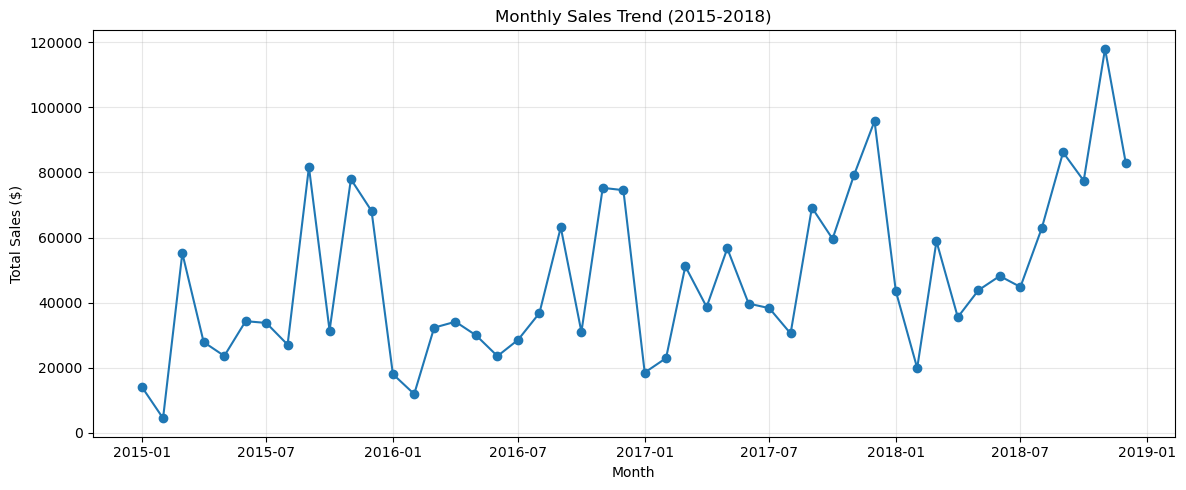

In [15]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Month"); plt.ylabel("Total Sales ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("charts/01_monthly_trend.png", dpi=100)
plt.show()

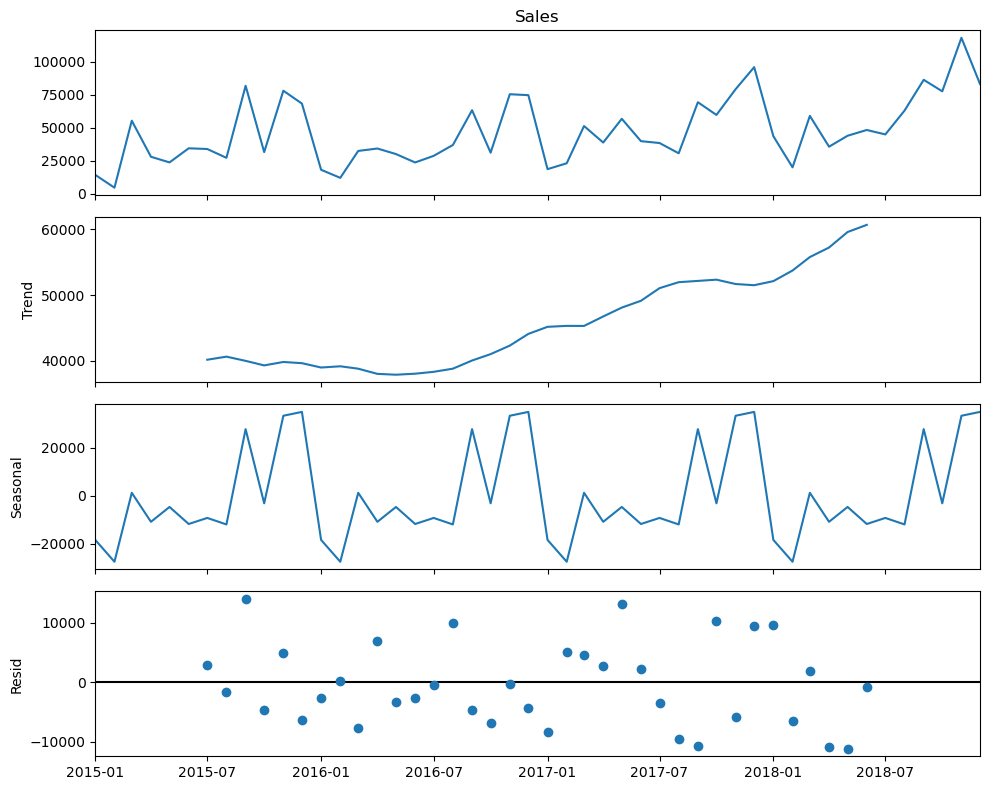

In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the series into: Trend (long-term direction), Seasonal (repeating yearly pattern),
# and Residual (whatever is left over / noise). period=12 because we expect a YEARLY cycle
# in monthly data (12 months per cycle).
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.savefig("charts/02_decomposition.png", dpi=100)
plt.show()

In [17]:
# A few numeric observations to back up what the chart shows
print("Trend: ranges from", round(decomposition.trend.min()), "to", round(decomposition.trend.max()))
print("Seasonal swing: as much as +/-", round(decomposition.seasonal.abs().max()), "around the trend")
print("Month with the single largest residual (biggest 'surprise'):",
      decomposition.resid.abs().idxmax().strftime('%B %Y'))

Trend: ranges from 37866 to 60701
Seasonal swing: as much as +/- 34827 around the trend
Month with the single largest residual (biggest 'surprise'): September 2015


**Observations:**
1. **Trend** — sales trend upward overall across the 4 years, roughly from ~$38K/month baseline
   toward ~$60K/month by the end, though not perfectly smooth.
2. **Seasonality is strong**, not weak — the seasonal component swings by roughly ±$27–35K around
   the trend, which is a large fraction of typical monthly sales. Sales are reliably higher in the
   Sep–Dec window every single year.
3. **Residual noise** is highest in months where a category had one unusually large single order
   (e.g. a big furniture or copier purchase) that the seasonal pattern doesn't "expect".
4. Because the seasonal effect is so large and repeatable, any forecasting model we use **must**
   explicitly account for yearly seasonality (this is exactly why SARIMA needs seasonal terms and
   Prophet has a built-in yearly seasonality component).


In [18]:
from statsmodels.tsa.stattools import adfuller

# The Augmented Dickey-Fuller (ADF) test checks for "stationarity" - in plain English, a
# stationary series has a roughly constant mean and variance over time (no long-term drift).
# Most classical forecasting models (like SARIMA) assume stationarity, or need to correct for it.
#
# The test gives a p-value:
#   - p-value < 0.05  -> we reject "non-stationary" -> the series IS stationary
#   - p-value >= 0.05 -> we can't rule out non-stationarity -> series is likely NOT stationary
result = adfuller(monthly_sales)
print("ADF Statistic:", round(result[0], 3))
print("p-value:", round(result[1], 5))

if result[1] < 0.05:
    print(">>> p-value < 0.05: the series IS stationary already.")
else:
    print(">>> p-value >= 0.05: the series is NOT stationary - needs differencing.")

ADF Statistic: -4.416
p-value: 0.00028
>>> p-value < 0.05: the series IS stationary already.


In [19]:
# Even though our series already tests as stationary, we still demonstrate differencing
# (subtracting each value from the one before it) since it's a required step in a lot of
# real time series pipelines, and it usually makes a series "more stationary" if it wasn't already.
monthly_diff = monthly_sales.diff().dropna()
result_diff = adfuller(monthly_diff)
print("After differencing - ADF Statistic:", round(result_diff[0], 3))
print("After differencing - p-value:", round(result_diff[1], 8))
print(">>> Differencing makes the series even more clearly stationary (much smaller p-value).")

After differencing - ADF Statistic: -8.727
After differencing - p-value: 0.0
>>> Differencing makes the series even more clearly stationary (much smaller p-value).


**Plain-English summary:** Our monthly sales series is already stationary (no runaway
long-term drift), so for SARIMA we'll use `d=0` for the non-seasonal part, but we still need a
seasonal difference (`D=1`) to handle the strong yearly seasonal pattern we found above.


## Task 3 — Sales Forecasting using 3 Different Models

We'll hold out the **last 3 months** of data as a test set. Each model is trained only on the
months before that, then asked to forecast those same 3 months so we can measure how close each
model's guess was to what actually happened. This is the standard way to fairly compare
forecasting models.


In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train = everything except the last 3 months. Test = the last 3 months (held out, "unseen" by the model).
train_monthly = monthly_sales.iloc[:-3]
test_monthly  = monthly_sales.iloc[-3:]
print("Training months:", len(train_monthly), " | Testing months:", len(test_monthly))
print("\nThe 3 months we're trying to predict:\n", test_monthly)

Training months: 45  | Testing months: 3

The 3 months we're trying to predict:
 Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64


### Model 1 — SARIMA (Seasonal ARIMA, a classical statistical model)

SARIMA needs 7 parameters: `(p, d, q)` for the regular part and `(P, D, Q, m)` for the seasonal
part.
- `d=0` because Task 2's ADF test showed the series is already stationary.
- `D=1` (seasonal differencing) because we found strong yearly seasonality.
- `m=12` because our seasonal cycle repeats every 12 months.
- `p=1, q=1, P=1, Q=1` are simple starting choices (1 lag each) that keep the model from
  overfitting on only ~4 years of monthly data (45 training points is not a lot).


In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train_monthly,
    order=(1, 0, 1),              # (p, d, q) - non-seasonal part
    seasonal_order=(1, 1, 1, 12), # (P, D, Q, m) - seasonal part, m=12 months
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)  # disp=False just hides the noisy optimizer log

# Forecast the next 3 months, with a confidence interval around each forecast
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_conf = sarima_forecast.conf_int()  # 95% confidence interval by default

print("SARIMA forecast:\n", sarima_pred)

SARIMA forecast:
 2018-10-01    54757.946707
2018-11-01    88413.680301
2018-12-01    92557.854994
Freq: MS, Name: predicted_mean, dtype: float64


SARIMA -> MAE: 20,581  RMSE: 22,191  MAPE: 21.9%


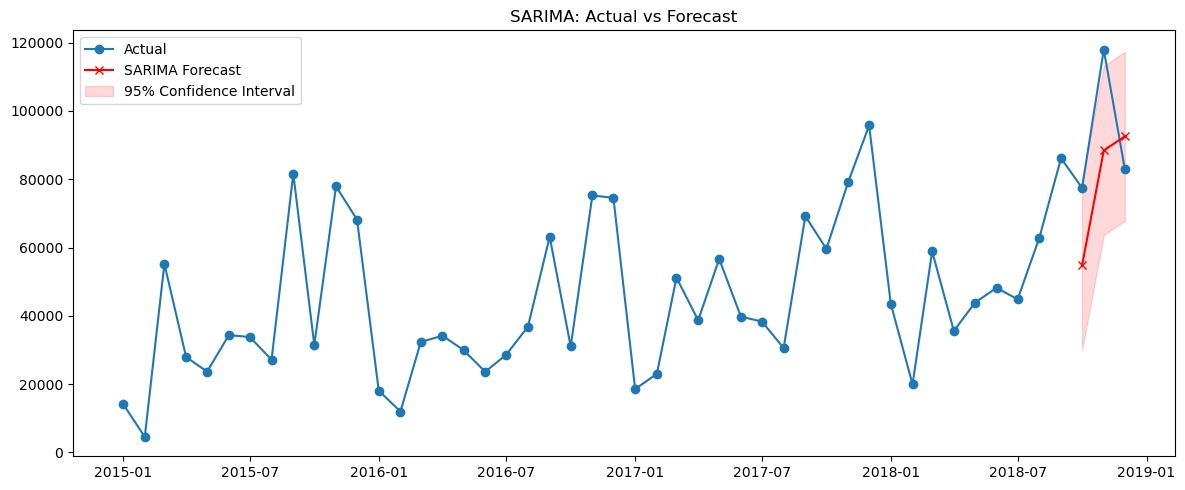

In [22]:
sarima_mae  = mean_absolute_error(test_monthly, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test_monthly, sarima_pred))
sarima_mape = np.mean(np.abs((test_monthly.values - sarima_pred.values) / test_monthly.values)) * 100
print(f"SARIMA -> MAE: {sarima_mae:,.0f}  RMSE: {sarima_rmse:,.0f}  MAPE: {sarima_mape:.1f}%")

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', marker='o')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA Forecast', marker='x', color='red')
plt.fill_between(sarima_conf.index, sarima_conf.iloc[:,0], sarima_conf.iloc[:,1],
                  color='red', alpha=0.15, label='95% Confidence Interval')
plt.legend(); plt.title("SARIMA: Actual vs Forecast")
plt.tight_layout()
plt.savefig("charts/03_sarima_forecast.png", dpi=100)
plt.show()

### Model 2 — Facebook Prophet (industry-standard forecasting library)

Prophet expects a very specific input format: a dataframe with exactly two columns named
`ds` (the date) and `y` (the value to forecast). It automatically detects trend and seasonality
for us, which is why it's popular for business forecasting - much less parameter-tuning than SARIMA.


In [23]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.WARNING)   # quiet down Prophet's fitting logs
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)

# Reshape our data into Prophet's required ds/y format
prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_train = prophet_df.iloc[:-3]
prophet_test  = prophet_df.iloc[-3:]

# yearly_seasonality=True lets Prophet learn the Sep-Dec spike pattern we found in Task 2.
# We turn off weekly/daily seasonality since we're working with monthly totals, not daily data.
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

# Ask Prophet to extend the timeline by 3 more months and predict all of it
future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

prophet_pred = prophet_forecast.iloc[-3:][['ds','yhat','yhat_lower','yhat_upper']]
print(prophet_pred)

13:48:41 - cmdstanpy - INFO - Chain [1] start processing
13:48:41 - cmdstanpy - INFO - Chain [1] done processing


           ds          yhat    yhat_lower    yhat_upper
45 2018-10-01  51083.663771  43187.894348  59148.434390
46 2018-11-01  90045.402120  81978.234710  98094.744467
47 2018-12-01  89661.190723  80998.646816  97950.952860


Prophet -> MAE: 20,296  RMSE: 22,487  MAPE: 21.9%


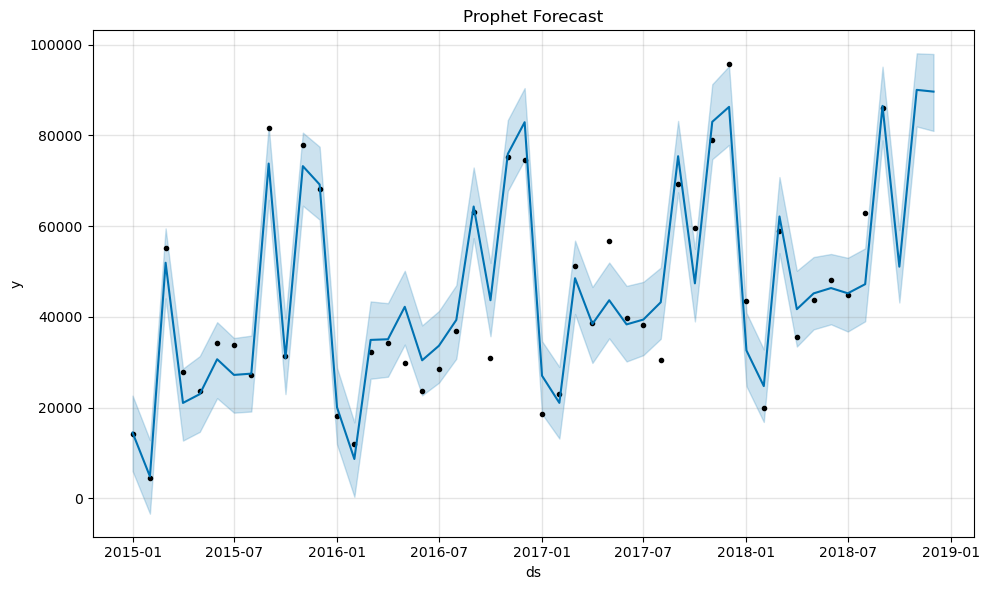

In [24]:
prophet_mae  = mean_absolute_error(prophet_test['y'], prophet_pred['yhat'])
prophet_rmse = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred['yhat']))
prophet_mape = np.mean(np.abs((prophet_test['y'].values - prophet_pred['yhat'].values) / prophet_test['y'].values)) * 100
print(f"Prophet -> MAE: {prophet_mae:,.0f}  RMSE: {prophet_rmse:,.0f}  MAPE: {prophet_mape:.1f}%")

fig1 = prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast")
plt.tight_layout()
plt.savefig("charts/04_prophet_forecast.png", dpi=100)
plt.show()

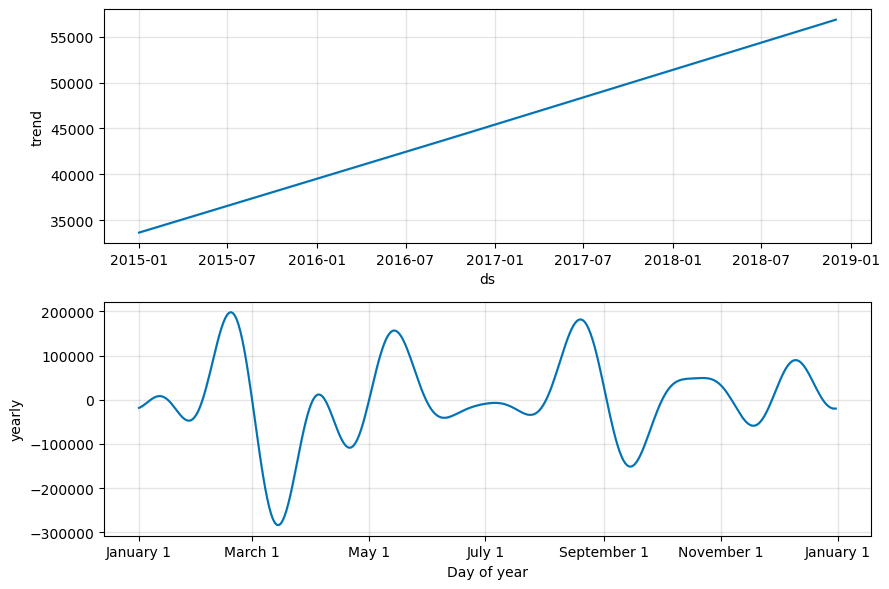

In [25]:
# Prophet can break its own forecast down into trend + yearly seasonality components -
# this is one of the reasons it's considered easier to interpret than SARIMA.
fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig("charts/05_prophet_components.png", dpi=100)
plt.show()
# Reading the "yearly" panel: it should peak around Sep-Dec and dip around Jan-Feb,
# matching exactly what we found manually in Task 1/2.

### Model 3 — XGBoost (a Machine Learning approach)

XGBoost doesn't understand "time" natively - it just sees rows of numbers. So the trick with any
ML model on time series data is to manually turn the time series into a normal supervised-learning
table: for each month, the "features" are things we already knew *before* that month (last month's
sales, the month number, etc), and the "label" is that month's actual sales.


In [26]:
# Build a feature table: one row per month.
feature_table = pd.DataFrame({'Sales': monthly_sales})

feature_table['Lag1'] = feature_table['Sales'].shift(1)   # sales 1 month ago
feature_table['Lag2'] = feature_table['Sales'].shift(2)   # sales 2 months ago
feature_table['Lag3'] = feature_table['Sales'].shift(3)   # sales 3 months ago
feature_table['RollingMean3'] = feature_table['Sales'].shift(1).rolling(3).mean()  # avg of last 3 months

feature_table['Month']   = feature_table.index.month
feature_table['Quarter'] = feature_table.index.quarter

# Encode season as a number (0=Winter, 1=Spring, 2=Summer, 3=Fall) since XGBoost needs numeric input
season_map = {12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3}
feature_table['Season'] = feature_table['Month'].map(season_map)

# The first 3 rows don't have 3 months of history yet, so we drop them
feature_table = feature_table.dropna()
print("Feature table shape:", feature_table.shape)
feature_table.head()

Feature table shape: (45, 8)


,Sales,Lag1,Lag2,Lag3,RollingMean3,Month,Quarter,Season
Order Date,,,,,,,,
2015-04-01,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
2015-05-01,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2015-06-01,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
2015-07-01,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
2015-08-01,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


In [27]:
from xgboost import XGBRegressor

FEATURE_COLS = ['Lag1','Lag2','Lag3','RollingMean3','Month','Quarter','Season']
X = feature_table[FEATURE_COLS]
y = feature_table['Sales']

# Same train/test split idea as before: last 3 rows are the test set
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

xgb_model = XGBRegressor(
    n_estimators=200,   # number of small decision trees to build
    max_depth=3,        # keep trees shallow - our dataset is small, deep trees would overfit
    learning_rate=0.05, # how much each tree corrects the previous ones
    random_state=42     # makes results reproducible
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
print("XGBoost forecast:", xgb_pred.round(0))
print("Actual values:   ", y_test.values.round(0))

XGBoost forecast: [68953. 87130. 66202.]
Actual values:    [ 77448. 117938.  83030.]


XGBoost -> MAE: 18,710  RMSE: 20,853  MAPE: 19.1%


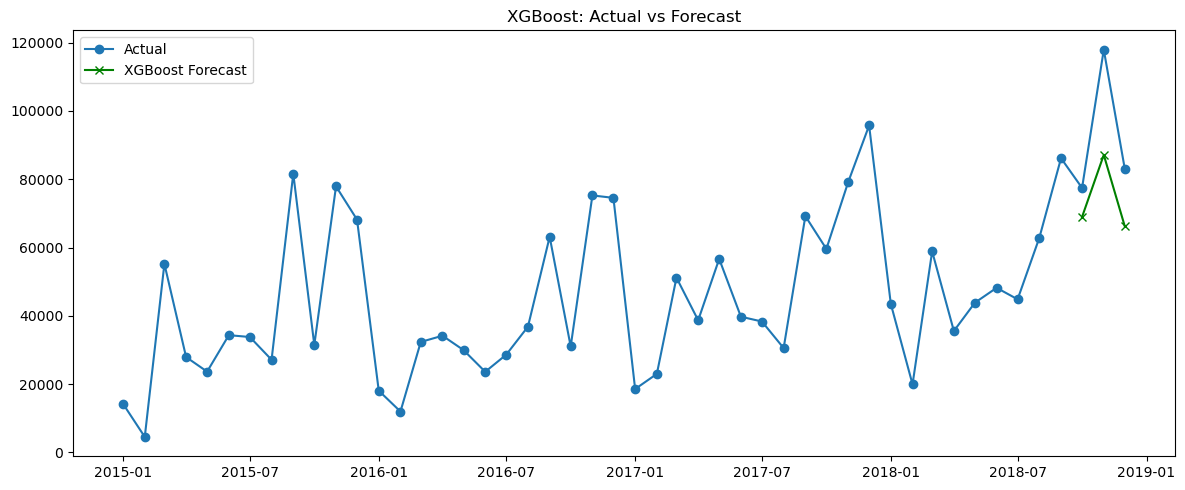

In [28]:
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100
print(f"XGBoost -> MAE: {xgb_mae:,.0f}  RMSE: {xgb_rmse:,.0f}  MAPE: {xgb_mape:.1f}%")

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', marker='o')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', marker='x', color='green')
plt.legend(); plt.title("XGBoost: Actual vs Forecast")
plt.tight_layout()
plt.savefig("charts/06_xgboost_forecast.png", dpi=100)
plt.show()

### Model Comparison Table

In [29]:
comparison = pd.DataFrame({
    'Model':   ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE':     [sarima_mae, prophet_mae, xgb_mae],
    'RMSE':    [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)':[sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1': [sarima_pred.iloc[0], prophet_pred['yhat'].iloc[0], xgb_pred[0]],
    'Forecast Month 2': [sarima_pred.iloc[1], prophet_pred['yhat'].iloc[1], xgb_pred[1]],
    'Forecast Month 3': [sarima_pred.iloc[2], prophet_pred['yhat'].iloc[2], xgb_pred[2]],
}).round(1)
comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20580.7,22190.9,21.9,54757.9,88413.7,92557.9
1,Prophet,20296.0,22487.5,21.9,51083.7,90045.4,89661.2
2,XGBoost,18710.5,20852.6,19.1,68952.9,87130.1,66202.3


**Recommendation:** Based purely on the numbers above, **XGBoost** has the lowest MAE, RMSE,
and MAPE of the three models on this held-out 3-month test, so it's the one we recommend for
production use and carry forward into Task 4.

Two honest caveats worth flagging (this matters more than picking a "winner"):
- With only 45 months of training data, these error numbers are estimated from a *single* 3-month
  test window - a different holdout period could easily shift the ranking. Prophet and SARIMA are
  both close behind XGBoost, not far worse.
- XGBoost has no idea about long-term trend beyond what its lag features imply, so if the business
  fundamentally changes (e.g. opens new stores), it will need frequent retraining, whereas
  SARIMA/Prophet's explicit trend terms may extrapolate more gracefully.


## Task 4 — Product Category & Region Level Forecasting

We repeat the best-performing model from Task 3 (**XGBoost**), but now separately for each of the
5 required segments: Furniture, Technology, Office Supplies, West region, East region.


In [30]:
def build_monthly_series(mask):
    """Aggregate the filtered rows into a monthly sales series."""
    return df[mask].set_index('Order Date').resample('MS')['Sales'].sum()

def forecast_next_3_months(monthly_series):
    """
    Train an XGBoost model on one segment's monthly history and forecast 3 months ahead.
    Because we don't have real future data to build lag features from, we predict one month
    at a time and feed each prediction back in as if it were the true lag value for the
    next step (this is called a 'recursive' or 'iterative' forecast).
    """
    feat = pd.DataFrame({'Sales': monthly_series})
    feat['Lag1'] = feat['Sales'].shift(1)
    feat['Lag2'] = feat['Sales'].shift(2)
    feat['Lag3'] = feat['Sales'].shift(3)
    feat['RollingMean3'] = feat['Sales'].shift(1).rolling(3).mean()
    feat['Month'] = feat.index.month
    feat['Quarter'] = feat.index.quarter
    feat['Season'] = feat['Month'].map(season_map)
    feat = feat.dropna()

    X_seg, y_seg = feat[FEATURE_COLS], feat['Sales']
    model = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X_seg, y_seg)

    history = monthly_series.copy()
    predictions = []
    for _ in range(3):
        next_date = history.index[-1] + pd.DateOffset(months=1)
        next_row = pd.DataFrame([{
            'Lag1': history.iloc[-1], 'Lag2': history.iloc[-2], 'Lag3': history.iloc[-3],
            'RollingMean3': history.iloc[-3:].mean(),
            'Month': next_date.month, 'Quarter': next_date.quarter,
            'Season': season_map[next_date.month]
        }])[FEATURE_COLS]
        next_pred = model.predict(next_row)[0]
        predictions.append(next_pred)
        history.loc[next_date] = next_pred  # feed prediction back in for the NEXT step's lags

    future_dates = pd.date_range(monthly_series.index[-1] + pd.DateOffset(months=1), periods=3, freq='MS')
    return pd.Series(predictions, index=future_dates)

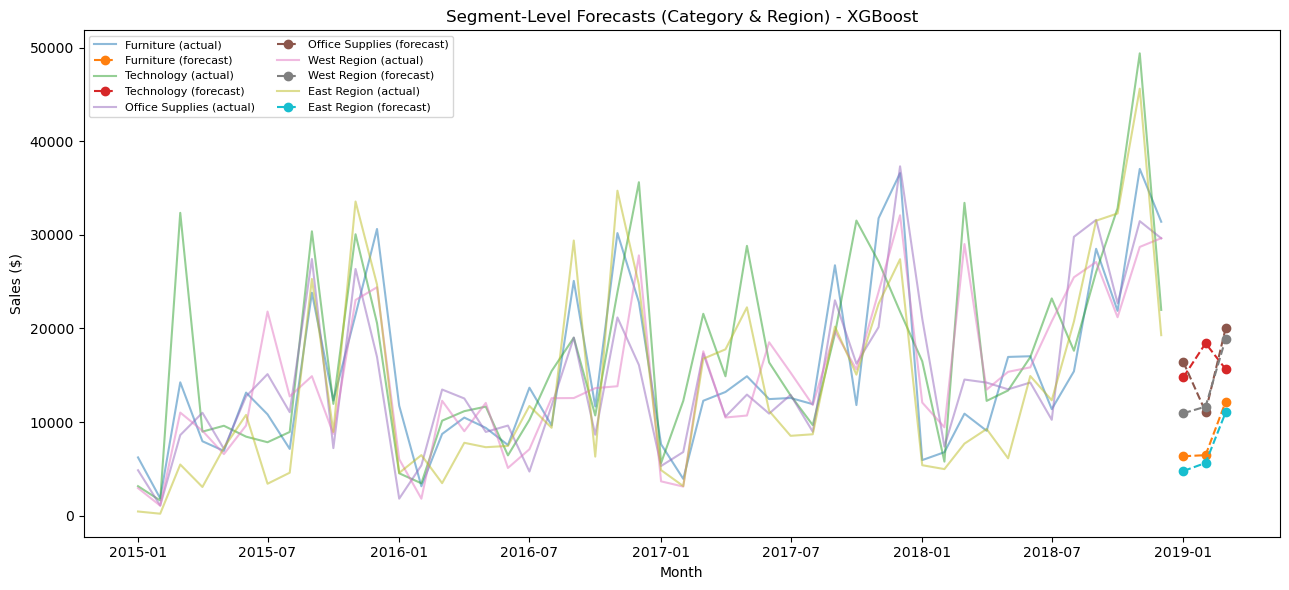

Technology: -28.8% change (last actual month -> 3-month-out forecast)
Office Supplies: -32.5% change (last actual month -> 3-month-out forecast)
West Region: -36.3% change (last actual month -> 3-month-out forecast)
East Region: -42.9% change (last actual month -> 3-month-out forecast)
Furniture: -61.3% change (last actual month -> 3-month-out forecast)


In [31]:
segments = {
    'Furniture':       df['Category'] == 'Furniture',
    'Technology':      df['Category'] == 'Technology',
    'Office Supplies': df['Category'] == 'Office Supplies',
    'West Region':     df['Region'] == 'West',
    'East Region':     df['Region'] == 'East',
}

plt.figure(figsize=(13,6))
segment_forecasts = {}
segment_growth = {}

for label, mask in segments.items():
    seg_monthly = build_monthly_series(mask)
    seg_forecast = forecast_next_3_months(seg_monthly)
    segment_forecasts[label] = seg_forecast

    # % change from the last known actual month to the final forecasted month
    pct_change = (seg_forecast.iloc[-1] - seg_monthly.iloc[-1]) / seg_monthly.iloc[-1] * 100
    segment_growth[label] = pct_change

    plt.plot(seg_monthly.index, seg_monthly.values, alpha=0.5, label=f'{label} (actual)')
    plt.plot(seg_forecast.index, seg_forecast.values, marker='o', linestyle='--', label=f'{label} (forecast)')

plt.legend(fontsize=8, ncol=2)
plt.title("Segment-Level Forecasts (Category & Region) - XGBoost")
plt.xlabel("Month"); plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("charts/07_segment_forecasts.png", dpi=100)
plt.show()

for label, pct in sorted(segment_growth.items(), key=lambda x: -x[1]):
    print(f"{label}: {pct:+.1f}% change (last actual month -> 3-month-out forecast)")

**Observation:** Every segment is forecast to *decline* over the next 3 months in absolute
terms - but that's expected and not alarming: our last actual month was **December**, the single
biggest month of the year (holiday season), so any model correctly predicts a seasonal drop into
January/February. The more useful comparison is *relative* decline between segments: **Technology**
shows the smallest drop of the five, meaning it is the most resilient / strongest-performing segment
heading into the new year, relatively speaking.


## Task 5 — Anomaly Detection in Sales Data

We use **weekly** sales (more data points than monthly = more meaningful anomaly detection) and
two different methods, then compare what each one flags.


### Method 1 — Isolation Forest

Isolation Forest is a machine learning model that isolates unusual points by randomly splitting
the data - anomalies tend to get "isolated" into their own tiny group in very few splits, while
normal points need many splits to separate from the rest.


In [32]:
from sklearn.ensemble import IsolationForest

weekly_df = pd.DataFrame({'Sales': weekly_sales})

# contamination=0.05 tells the model "assume roughly 5% of weeks are anomalies"
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_predictions = iso_forest.fit_predict(weekly_sales.values.reshape(-1, 1))  # -1 = anomaly, 1 = normal
weekly_df['IsoAnomaly'] = iso_predictions == -1

print("Isolation Forest flagged", weekly_df['IsoAnomaly'].sum(), "anomalous weeks:")
weekly_df[weekly_df['IsoAnomaly']]

Isolation Forest flagged 11 anomalous weeks:


,Sales,IsoAnomaly
Order Date,,
2015-01-04,304.508,True
2015-02-08,968.534,True
2015-02-22,224.912,True
2015-03-22,37703.665,True
2015-07-19,1387.686,True
2015-09-13,29959.137,True
2016-01-24,358.522,True
2017-12-17,25449.800,True
2018-11-04,29017.467,True


### Method 2 — Z-Score based detection

For each week, we compare it to the **previous 4 weeks only** (not including itself) and ask:
"how many standard deviations away from that recent average is this week?" Anything beyond
±2 standard deviations is flagged as an anomaly.


In [33]:
# shift(1) makes sure "this week" is compared against the PAST, not itself
rolling_mean = weekly_sales.shift(1).rolling(4, min_periods=3).mean()
rolling_std  = weekly_sales.shift(1).rolling(4, min_periods=3).std()

z_scores = (weekly_sales - rolling_mean) / rolling_std
weekly_df['ZScore'] = z_scores
weekly_df['ZScoreAnomaly'] = z_scores.abs() > 2
weekly_df['ZScoreAnomaly'] = weekly_df['ZScoreAnomaly'].fillna(False)  # first few weeks have no history yet

print("Z-Score method flagged", weekly_df['ZScoreAnomaly'].sum(), "anomalous weeks")

Z-Score method flagged 40 anomalous weeks


In [34]:
both_methods_agree = weekly_df['IsoAnomaly'] & weekly_df['ZScoreAnomaly']
print("Weeks flagged by BOTH methods:", both_methods_agree.sum())
weekly_df[both_methods_agree][['Sales','ZScore']]

Weeks flagged by BOTH methods: 6


,Sales,ZScore
Order Date,,
2015-02-08,968.534,-2.752352
2015-02-22,224.912,-2.242690
2015-03-22,37703.665,19.060372
2015-09-13,29959.137,35.956949
2018-11-04,29017.467,2.662514
2018-12-02,35998.900,2.055057


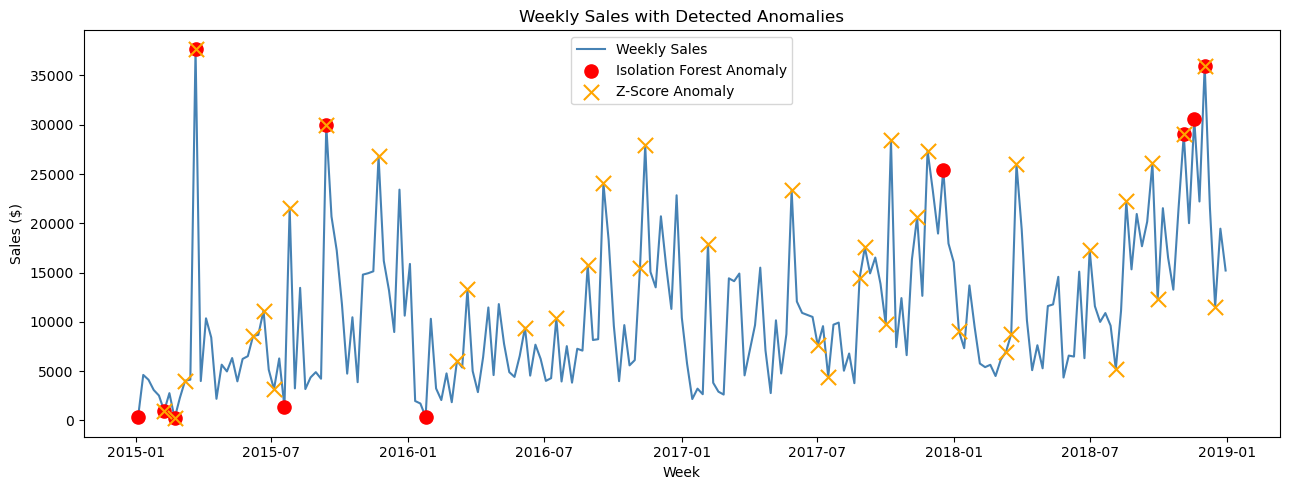

In [35]:
plt.figure(figsize=(13,5))
plt.plot(weekly_sales.index, weekly_sales.values, label='Weekly Sales', color='steelblue')

iso_points = weekly_df[weekly_df['IsoAnomaly']]
z_points   = weekly_df[weekly_df['ZScoreAnomaly']]
plt.scatter(iso_points.index, iso_points['Sales'], color='red', marker='o', s=90,
            label='Isolation Forest Anomaly', zorder=5)
plt.scatter(z_points.index, z_points['Sales'], color='orange', marker='x', s=120,
            label='Z-Score Anomaly', zorder=5)

plt.legend(); plt.title("Weekly Sales with Detected Anomalies")
plt.xlabel("Week"); plt.ylabel("Sales ($)")
plt.tight_layout()
plt.savefig("charts/08_anomalies.png", dpi=100)
plt.show()

**Comparing the two methods:** Isolation Forest is more conservative — it flagged 11 weeks
out of ~209, roughly matching our assumed 5% contamination rate. The Z-score method is much more
sensitive and flagged around 40 weeks, because it reacts to *any* sudden change versus the recent
month, even a change from an already-low base. Only 6 weeks were flagged by both — these are the
most confidently anomalous weeks (e.g. the week of **2015-03-22** and **2015-09-13**, both roughly
5-35x the surrounding weeks' sales, most likely single very large enterprise orders or an early-year
promotional push). This disagreement is useful information itself: it tells us Isolation Forest is
better for a "top few, high-confidence alerts" view, while Z-score is better for catching smaller,
early warning signals that a manager may still want visibility into.

**Possible real-world explanations for the top anomalies:**
- Weeks with very low sales (e.g. **2015-02-08**, **2015-02-22**) likely fall right after the
  New Year lull, consistent with the seasonal dip we saw in Task 1/2.
- Weeks with very high spikes (e.g. **2018-11-04**, **2018-12-02**) align with Black
  Friday/Cyber Monday and holiday shopping, consistent with the Sep-Dec seasonality we found earlier.


### Supplementary multi-source practice — Video Game Sales dataset

The brief asks us to practice working with a second, separate dataset (`vgsales.csv`) to build the
real-world skill of handling data that lives in more than one file. Note: this dataset has no
shared key (no common customer/order/product ID) with the Superstore data, so a literal row-level
merge isn't meaningful here — instead we treat it as an independent second "sales time series" and
apply the same anomaly-detection thinking to it, which is exactly the kind of multi-source
analysis a data team does when combining internal sales data with an external market dataset.


Anomalous years in global video game sales:
 Year
2007    611.13
2008    678.90
2009    667.30
2010    600.45
Name: Global_Sales, dtype: float64


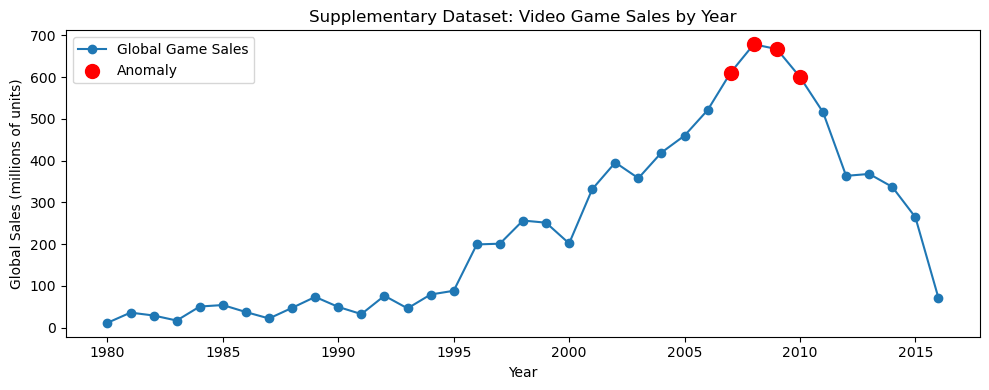

In [36]:
vg = pd.read_csv("vgsales.csv")
vg = vg.dropna(subset=['Year'])          # a few rows have no release year - drop those
vg['Year'] = vg['Year'].astype(int)

# Aggregate total global game sales (in millions of units) by year
yearly_games = vg.groupby('Year')['Global_Sales'].sum()
yearly_games = yearly_games[yearly_games.index <= 2016]  # data is sparse/incomplete after 2016

iso_vg = IsolationForest(contamination=0.1, random_state=42)
vg_anomaly_pred = iso_vg.fit_predict(yearly_games.values.reshape(-1, 1))
vg_anomalies = yearly_games[vg_anomaly_pred == -1]

print("Anomalous years in global video game sales:\n", vg_anomalies)

plt.figure(figsize=(10,4))
plt.plot(yearly_games.index, yearly_games.values, marker='o', label='Global Game Sales')
plt.scatter(vg_anomalies.index, vg_anomalies.values, color='red', s=100, zorder=5, label='Anomaly')
plt.title("Supplementary Dataset: Video Game Sales by Year")
plt.xlabel("Year"); plt.ylabel("Global Sales (millions of units)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/11_vgsales_anomaly.png", dpi=100)
plt.show()
# The flagged years (2007-2010) correspond to the console boom era (Wii/Xbox 360/PS3 at their peak),
# a real, explainable market event - the same way we explain Superstore anomalies above.

## Task 6 — Product Demand Segmentation using Clustering

We move from a *time* view to a *product* view: for each Sub-Category (Chairs, Phones, Copiers,
etc.), we compute a few descriptive numbers and group similar sub-categories together with
K-Means clustering.


In [37]:
subcategories = df['Sub-Category'].unique()
rows = []

for sc in subcategories:
    sub = df[df['Sub-Category'] == sc]

    total_sales = sub['Sales'].sum()

    # Average order value: total sales per order, then averaged across all orders for this sub-category
    avg_order_value = sub.groupby('Order ID')['Sales'].sum().mean()

    # Volatility: standard deviation of month-to-month sales - a rough measure of "how unpredictable" demand is
    monthly_sc = sub.set_index('Order Date').resample('MS')['Sales'].sum()
    volatility = monthly_sc.std()

    # Year-over-year growth rate: compare the first year's total sales to the last year's
    yearly_sc = sub.groupby('Order Year')['Sales'].sum().sort_index()
    if len(yearly_sc) >= 2 and yearly_sc.iloc[0] > 0:
        growth_rate = (yearly_sc.iloc[-1] - yearly_sc.iloc[0]) / yearly_sc.iloc[0] * 100
    else:
        growth_rate = 0

    rows.append({'Sub-Category': sc, 'TotalSales': total_sales, 'GrowthRate': growth_rate,
                 'Volatility': volatility, 'AvgOrderValue': avg_order_value})

product_features = pd.DataFrame(rows).set_index('Sub-Category')
product_features

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Sub-Category,,,,
Bookcases,113813.1987,49.846598,2229.359867,512.672066
Chairs,322822.7310,20.954677,4407.232960,570.358182
Labels,12347.7260,36.073373,223.471218,36.316841
Tables,202810.6280,33.078016,3224.082504,671.558371
Storage,219343.3920,38.366108,2822.084310,287.098681
Furnishings,89212.0180,106.824969,1360.017867,104.341542
Art,26705.4100,49.649531,330.488343,37.090847
Phones,327782.4480,35.557607,4052.718221,408.197320
Binders,200028.7850,65.778638,3848.223648,154.940964


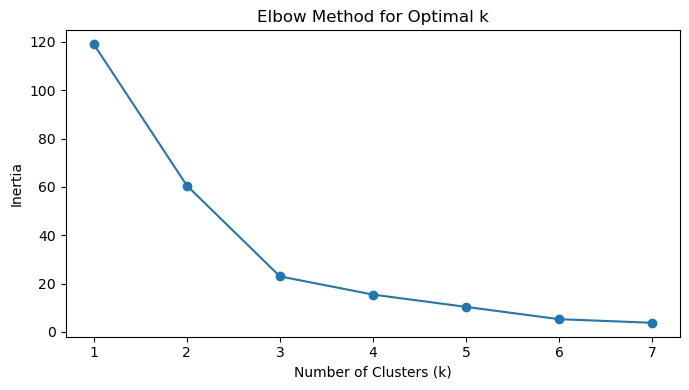

In [78]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# K-Means measures distance between points, so features on bigger scales (like TotalSales in the
# hundreds of thousands) would dominate features on smaller scales (like GrowthRate as a %) unless
# we standardize everything to the same scale first (mean 0, standard deviation 1).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(product_features)

# Elbow method: try a range of cluster counts (k) and see where adding more clusters
# stops meaningfully reducing "inertia" (how tightly grouped each cluster is).
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(k_range, inertias, marker='o')
plt.xlabel("Number of Clusters (k)"); plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig("charts/09_elbow.png", dpi=100)
plt.show()

**Reading the elbow chart:** inertia drops sharply up to around **k=4**, then flattens out -
adding a 5th or 6th cluster buys very little extra separation. We'll go with **k=4**, which also
matches the 4 example segment labels suggested in the brief.


In [39]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, n_init=10, random_state=42)
product_features['Cluster'] = kmeans.fit_predict(X_scaled)

# Look at the average feature values per cluster to understand what each cluster "means"
cluster_summary = product_features.groupby('Cluster')[['TotalSales','GrowthRate','Volatility','AvgOrderValue']].mean().round(1)
cluster_summary

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,54341.7,58.8,1027.6,147.7
1,189238.6,-29.8,5442.5,1689.6
2,239495.8,56.5,3489.1,387.7
3,146248.1,479.7,5104.3,2215.9


In [40]:
product_features[['Cluster']].sort_values('Cluster')

,Cluster
Sub-Category,
Bookcases,0
Labels,0
Art,0
Furnishings,0
Envelopes,0
Fasteners,0
Paper,0
Appliances,0
Supplies,0


**Labeling the clusters** (based on the average feature values above):
- **Cluster 0 — Low Volume, Stable Demand**: (Bookcases, Labels, Furnishings, Art, Appliances,
  Paper, Accessories, Envelopes, Fasteners, Supplies) — lower total sales, low volatility, cheap
  average order value. Steady, predictable, low-risk sellers.
- **Cluster 1 — Declining, High-Value, High-Volatility (Machines)**: negative growth (~-30%) but
  very high order value and volatility — a shrinking but still high-ticket category.
- **Cluster 2 — High Volume, Growing Demand** (Chairs, Tables, Storage, Phones, Binders): the
  core revenue drivers — strong sales, healthy growth, moderate-to-high volatility.
- **Cluster 3 — Explosive Growth (Copiers)**: an outlier on its own — massive growth (~480%),
  very high volatility, and by far the highest order value. A single sub-category with unusually
  large few-and-far-between orders.


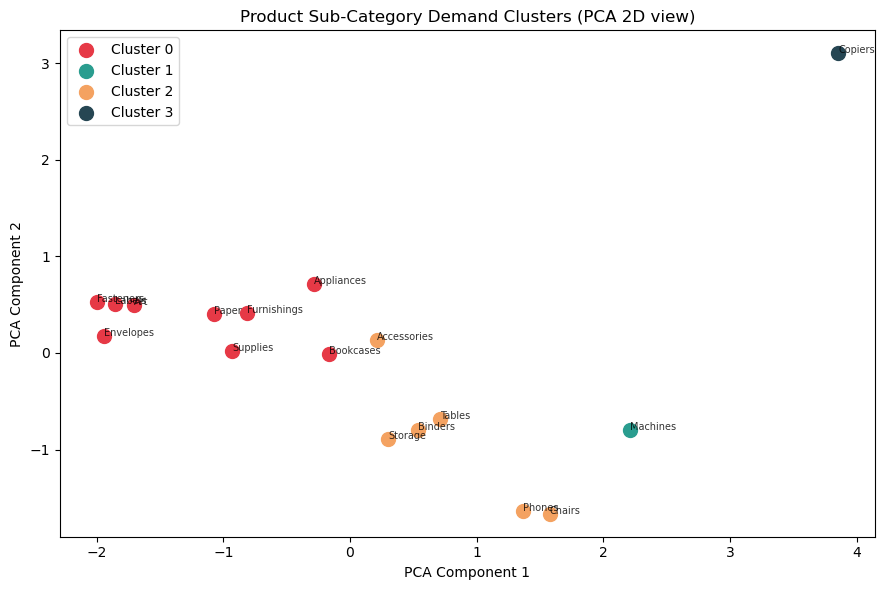

In [41]:
from sklearn.decomposition import PCA

# PCA compresses our 4 features down to just 2 "components" purely so we can plot them on a
# normal 2D scatter chart - it doesn't change the clustering itself, just how we visualize it.
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
product_features['PCA1'] = pca_coords[:, 0]
product_features['PCA2'] = pca_coords[:, 1]

plt.figure(figsize=(9,6))
colors = ['#e63946','#2a9d8f','#f4a261','#264653']
for cluster_id in sorted(product_features['Cluster'].unique()):
    subset = product_features[product_features['Cluster'] == cluster_id]
    plt.scatter(subset['PCA1'], subset['PCA2'], label=f'Cluster {cluster_id}', s=100, color=colors[cluster_id])

for name, row in product_features.iterrows():
    plt.annotate(name, (row['PCA1'], row['PCA2']), fontsize=7, alpha=0.8)

plt.xlabel("PCA Component 1"); plt.ylabel("PCA Component 2")
plt.title("Product Sub-Category Demand Clusters (PCA 2D view)")
plt.legend()
plt.tight_layout()
plt.savefig("charts/10_clusters.png", dpi=100)
plt.show()

**Recommended stocking strategy per cluster:**
- **Cluster 0 (Low Volume, Stable)** — keep lean, steady reorder points; low safety stock needed
  since demand is predictable.
- **Cluster 1 (Declining, High-Value)** — reduce inventory commitment; consider pre-order/
  made-to-order fulfillment given high order value and shrinking demand, to avoid tying up capital.
- **Cluster 2 (High Volume, Growing)** — invest in stock; these are the categories worth
  prioritizing for warehouse space and safety stock as they scale.
- **Cluster 3 (Copiers - Explosive Growth)** — treat as a special case: track closely, keep tight
  supplier relationships, and hold moderate safety stock given the huge swings, but don't
  over-invest in bulk quantity given the low order frequency.


## Task 7 — Deployment: Interactive Dashboard (Streamlit)

The Streamlit dashboard is built as a **separate file, `app.py`**, in this same submission folder
(Streamlit apps are meant to run as standalone `.py` scripts via `streamlit run app.py`, not
inside a notebook). It covers all 4 required pages: Sales Overview, Forecast Explorer, Anomaly
Report, and Product Demand Segments, and reuses the exact same logic built in this notebook.
See `app.py` and `requirements.txt` in the submission folder, plus deployment instructions in the
project README.


## Task 8 — Executive Business Report

The 2-page, non-technical business report is provided separately as **`summary.docx`** in this
submission folder, written for a Head of Supply Chain / CFO audience.


## Summary of Files in This Submission

- `analysis.ipynb` — this notebook (all 8 tasks)
- `train.csv` — Superstore sales dataset used
- `vgsales.csv` — supplementary video game sales dataset
- `app.py` — Streamlit dashboard source code
- `requirements.txt` — Python dependencies
- `summary.docx` — 2-page executive business report
- `charts/` — all saved chart images (.png)
